In [7]:
%matplotlib inline
import random
import time
import copy
import matplotlib.pyplot as plt

plt.style.use('ggplot')
random.seed(42)

In [8]:
# searching algorithms
def linear_search(arr, x):
    i = 1
    while i <= len(arr) and x != arr[i-1]:
        i = i + 1
    if i <= len(arr):
        location = i
    else:
        location = 0
    return location

def binary_search(arr, x):
    i = 1
    j = len(arr)
    while i < j:
        m = (i + j) // 2
        if x > arr[m-1]:
            i = m + 1
        else:
            j = m
    if x == arr[i-1]:
        location = i
    else:
        location = 0
    return location

In [9]:
# sorting algorithms
def bubble_sort(arr):
    n = len(arr)
    for i in range(1, n):
        for j in range(1, n - i + 1):
            if arr[j-1] > arr[j]:
                arr[j-1], arr[j] = arr[j], arr[j-1]
    return arr

def insertion_sort(arr):
    for j in range(2, len(arr) + 1):
        i = 1
        while arr[j-1] > arr[i-1]:
            i = i + 1
        m = arr[j-1]
        for k in range(0, j - i - 1 + 1):
            arr[j-1-k] = arr[j-2-k]
        arr[i-1] = m
    return arr

def merge(L1, L2):
    L = []
    L1 = list(L1)
    L2 = list(L2)
    while len(L1) > 0 and len(L2) > 0:
        if L1[0] < L2[0]:
            L.append(L1.pop(0))
        else:
            L.append(L2.pop(0))
        if len(L1) == 0:
            L.extend(L2)
            L2 = []
        elif len(L2) == 0:
            L.extend(L1)
            L1 = []
    return L

def merge_sort(arr):
    if len(arr) > 1:
        m = len(arr) // 2
        L1 = arr[:m]
        L2 = arr[m:]
        L1 = merge_sort(L1)
        L2 = merge_sort(L2)
        result = merge(L1, L2)
        arr[:] = result
    return arr

In [10]:
search_sizes = [10000, 20000, 40000, 80000]

linear_times = []
binary_times = []

for n in search_sizes:
    data = sorted(random.sample(range(n*10), n))
    target = data[-1]  # worst case

    start = time.time()
    linear_search(data, target)
    linear_times.append(time.time() - start)

    start = time.time()
    binary_search(data, target)
    binary_times.append(time.time() - start)

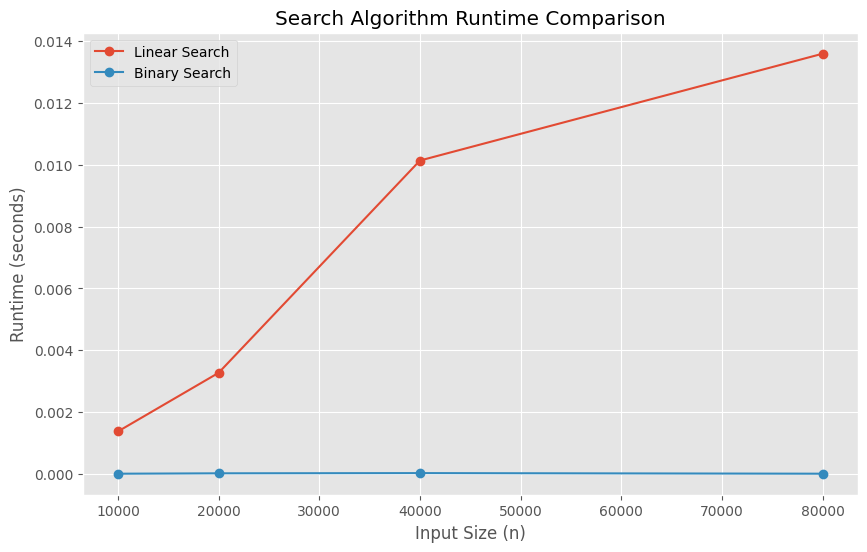

In [11]:
plt.figure(figsize=(10,6))
plt.plot(search_sizes, linear_times, marker='o', label="Linear Search")
plt.plot(search_sizes, binary_times, marker='o', label="Binary Search")
plt.xlabel("Input Size (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Search Algorithm Runtime Comparison")
plt.legend()
plt.show()

Discussion

**Search Algorithms:**
We picked the last element as the target so linear search would have to go
through the whole array every time. Looking at the plot, the runtime goes up
pretty steadily as n doubles, which is what you'd expect from O(n).

Binary search was honestly hard to see on the same graph because it barely
moves at all. It keeps halving the search space so even at n=80000 it finds
the answer in very few steps. It needs the array to be sorted first though,
which linear search doesn't.

In [14]:
sort_sizes = [1000, 2000, 4000, 8000]

bubble_times = []
insertion_times = []
merge_times = []

for n in sort_sizes:
    data = random.sample(range(n*10), n)

    b_arr = copy.deepcopy(data)
    start = time.time()
    bubble_sort(b_arr)
    bubble_times.append(time.time() - start)

    i_arr = copy.deepcopy(data)
    start = time.time()
    insertion_sort(i_arr)
    insertion_times.append(time.time() - start)

    m_arr = copy.deepcopy(data)
    start = time.time()
    merge_sort(m_arr)
    merge_times.append(time.time() - start)

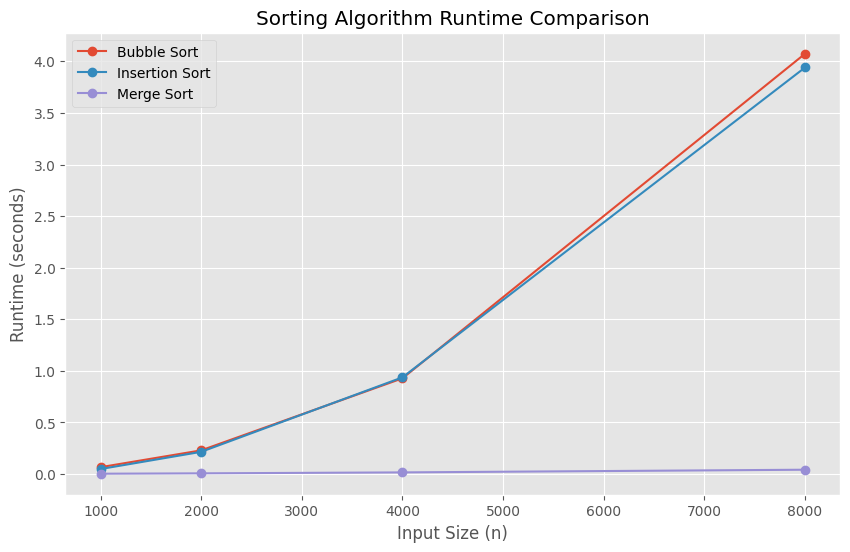

In [13]:
plt.figure(figsize=(10,6))
plt.plot(sort_sizes, bubble_times, marker='o', label="Bubble Sort")
plt.plot(sort_sizes, insertion_times, marker='o', label="Insertion Sort")
plt.plot(sort_sizes, merge_times, marker='o', label="Merge Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Sorting Algorithm Runtime Comparison")
plt.legend()
plt.show()

**Sorting Algorithms:**
We kept n between 1000 and 8000 because bubble sort started taking too long
beyond that, which actually says a lot about how badly it scales.

Bubble sort was the slowest by a clear margin. It goes through the whole array
on every pass swapping adjacent pairs, so time roughly quadruples every
time n doubles.

Insertion sort was faster even though it's also O(n²). It shifts elements
instead of swapping them and stops early once the right position is found,
so it does less work overall. It was noticeably quicker especially at n=8000.

Merge sort appeared differently. The curve barely rises compared to the
first two. Splitting the array recursively and merging keeps the operations
at O(n log n), though it uses extra memory for the temporary lists.


Overall, the gap between O(n²) and O(n log n) becomes obvious once n
gets large enough, and even the difference between bubble and insertion sort
at the same complexity class was bigger than expected.